In [ ]:
%pip install --upgrade ipython
%pip install mplfinance
%load_ext autoreload
%autoreload 2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 627.3/627.3 kB 3.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 30.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 6.3 MB/s eta 0:00:00
  Attempting uninstall: traitlets
    Found existing installation: traitlets 5.7.1
    Uninstalling traitlets-5.7.1:
      Successfully uninstalled traitlets-5.7.1
  Attempting uninstall: psutil
    Found existing installation: psutil 5.9.5
    Uninstalling psutil-5.9.5:
      Successfully uninstalled psutil-5.9.5
  Attempting uninstall: decorator
    Found existing installation: decorator 4.4.2
    Uninstalling decorator-4.4.2:
      Successfully uninstalled decorator-4.4.2
  Attempting uninstall: ipython
    Found existing installation: ipython 7.34.0
    Uninstalling ipython-7.34.0:
      Successfully uninstalled ipython-7.34.0
ERROR: pip's dependency re

# I. Thu thập dữ liệu:

- Dữ liệu được lấy trực tiếp từ trang https://data.binance.vision, dữ liệu được lấy từ tháng 01/2020 - 04/2026, timeframe 1h.

In [2]:
import pandas as pd

df = pd.read_parquet("BTCUSDT_1h.parquet")

print(df.info())
print(display(df.head()))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55488 entries, 0 to 55487
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   open_time                     55488 non-null  object 
 1   open                          55488 non-null  float64
 2   high                          55488 non-null  float64
 3   low                           55488 non-null  float64
 4   close                         55488 non-null  float64
 5   volume                        55488 non-null  float64
 6   close_time                    55488 non-null  object 
 7   quote_asset_volume            55488 non-null  float64
 8   number_of_trades              55488 non-null  int64  
 9   taker_buy_base_asset_volume   55488 non-null  float64
 10  taker_buy_quote_asset_volume  55488 non-null  float64
 11  ignore                        55488 non-null  int64  
dtypes: float64(8), int64(2), object(2)
memory usage: 5.1+ MB
Non

,open_time,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,taker_buy_quote_asset_volume,ignore
0,2020-01-01 00:00:00,7189.43,7190.52,7170.15,7171.55,2449.049,2020-01-01 00:59:59.999,1.757642e+07,3688,996.198,7.149371e+06,0
1,2020-01-01 01:00:00,7171.43,7225.00,7171.10,7210.24,3865.038,2020-01-01 01:59:59.999,2.783805e+07,6635,2340.878,1.686029e+07,0
2,2020-01-01 02:00:00,7210.38,7239.30,7206.46,7237.99,3228.365,2020-01-01 02:59:59.999,2.332481e+07,5120,1774.145,1.281847e+07,0
3,2020-01-01 03:00:00,7237.41,7239.74,7215.00,7221.65,2513.307,2020-01-01 03:59:59.999,1.816182e+07,4143,1245.065,8.996219e+06,0
4,2020-01-01 04:00:00,7221.80,7225.41,7211.22,7213.86,1176.666,2020-01-01 04:59:59.999,8.493631e+06,1966,586.864,4.236084e+06,0


None


- Biểu diễn 100 cột dữ liệu cuối cùng theo biểu đồ nến Nhật

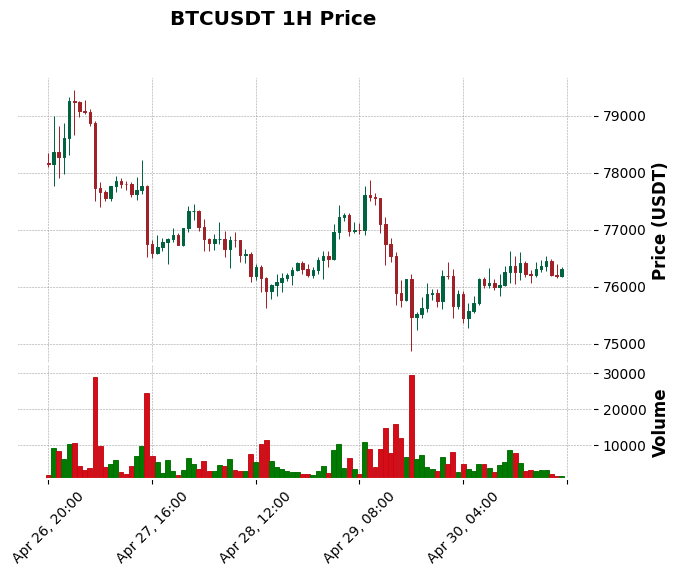

In [ ]:
import pandas as pd
import mplfinance as mpf

df = pd.read_parquet('BTCUSDT_1h.parquet')

df['open_time'] = pd.to_datetime(df['open_time'])

df = df.set_index('open_time')

ohlc = df[['open', 'high', 'low', 'close', 'volume']].copy()

mpf.plot(ohlc.tail(100), 
         type='candle', 
         style='charles',
         title='BTCUSDT 1H Price',
         ylabel='Price (USDT)',
         volume=True, 
         ylabel_lower='Volume')

- Trước khi tiến hành bước làm sạch và khám phá dữ liệu, tôi sẽ trích chọn ra một số đặc trưng cơ bản quan trọng trong bộ dữ liệu dữ liệu trên.

In [4]:
# Đưa về unix time để dễ xử lý hơn
df['unix_time'] = (df.index.astype('int64') // 10**6)

cols_to_keep = ['unix_time', 'high', 'low', 'close', 'volume']

extracted_df = df[cols_to_keep].copy()
extracted_df = extracted_df.set_index('unix_time')

print(display(extracted_df.head()))

,high,low,close,volume
unix_time,,,,
1577836800000,7190.52,7170.15,7171.55,2449.049
1577840400000,7225.00,7171.10,7210.24,3865.038
1577844000000,7239.30,7206.46,7237.99,3228.365
1577847600000,7239.74,7215.00,7221.65,2513.307
1577851200000,7225.41,7211.22,7213.86,1176.666


None


- Kiểm tra tính toàn vẹn của dữ liệu (kiểm tra khuyết thiếu và trùng lặp)

In [5]:
#Kiểm tra tính toàn vẹn của dữ liệu
print('Is duplicated =', extracted_df.duplicated().sum())
print('Is null:\n',extracted_df.isnull().sum())

Is duplicated = 0
Is null:
 high      0
low       0
close     0
volume    0
dtype: int64


# 2.Feature Engineering

- Tạo thêm các thuộc tính mới cho dữ liệu bằng cách tính các chỉ báo phổ biến được dùng nhiều trên thị trường. Và chỉ ra mối liên hệ của các thuộc tính. Bước này về cơ bản là sẽ dạy các chiến thuật giao dịch đã chứng minh được hiệu quả của con người cho máy học.

### 📈 Chỉ số Exponential Moving Average (EMA)
**Đường trung bình lũy thừa**

---

#### 🔍 Đặc điểm & Vai trò
*   **Xác định xu hướng:** Là công cụ đắc lực để nhận diện xu hướng chính của thị trường (Tăng, Giảm hoặc Đi ngang).
*   **Độ nhạy cao:** So với đường trung bình động đơn giản (**SMA**), **EMA** phản ứng nhanh hơn với các biến động giá gần nhất. 
*   **Giảm độ trễ:** Nhờ tính chất gán trọng số lớn hơn cho dữ liệu mới, EMA giúp nhà đầu tư nắm bắt tín hiệu sớm hơn.

> **💡 Tại sao chọn EMA thay vì SMA?**
> Chúng ta ưu tiên EMA vì nó có độ nhạy tối ưu với các thay đổi tức thời của thị trường. Điều này đặc biệt phù hợp trong việc dự đoán các xu hướng **ngắn hạn và trung hạn**, nơi mà tốc độ phản hồi là yếu tố sống còn.

#### 🧮 Công thức toán học
Giá trị EMA tại thời điểm $t$ được tính toán dựa trên giá trị EMA của thời điểm trước đó và giá đóng cửa hiện tại:

$$EMA_t = \left( V_t \times \frac{s}{1 + n} \right) + EMA_{y} \times \left( 1 - \frac{s}{1 + n} \right)$$

**Trong đó:**
*   $V_t$: Giá đóng cửa hôm nay (Value today).
*   $EMA_y$: Giá trị EMA của ngày hôm trước (Yesterday).
*   $s$: Hệ số làm mượt (Smoothing - thường mặc định bằng $2$).
*   $n$: Chu kỳ của EMA (Số ngày, ví dụ: 10, 20, 50).

> **💡 Ghi chú:** Hệ số nhân làm mượt $\alpha = \frac{2}{n+1}$ là yếu tố chính giúp EMA gán trọng số lớn hơn cho dữ liệu mới nhất, tạo nên sự nhạy bén so với đường SMA truyền thống.

---

In [ ]:
import src.feature_engineering as fe

#Bước này chỉ để chọn một số giá trị đại diện, không có ý nghĩa đặc biệt nào cả
periods_list = [3,5,8,10,12,14,15,20,21,26,30,34,40,50,100,150,200,250]
ema_df = fe.create_ema_list(extracted_df['close'], periods_list)
df_feat = pd.concat([extracted_df, ema_df], axis=1)

high       7190.520
low        7170.150
close      7171.550
volume     2449.049
ema_3      7171.550
ema_5      7171.550
ema_8      7171.550
ema_10     7171.550
ema_12     7171.550
ema_14     7171.550
ema_15     7171.550
ema_20     7171.550
ema_21     7171.550
ema_26     7171.550
ema_30     7171.550
ema_34     7171.550
ema_40     7171.550
ema_50     7171.550
ema_100    7171.550
ema_150    7171.550
ema_200    7171.550
ema_250    7171.550
Name: 1577836800000, dtype: float64


In [18]:
print(display(df_feat.head()))

,high,low,close,volume,ema_3,ema_5,ema_8,ema_10,ema_12,ema_14,...,ema_21,ema_26,ema_30,ema_34,ema_40,ema_50,ema_100,ema_150,ema_200,ema_250
unix_time,,,,,,,,,,,,,,,,,,,,,
1577836800000,7190.52,7170.15,7171.55,2449.049,7171.550000,7171.550000,7171.550000,7171.550000,7171.550000,7171.550000,...,7171.550000,7171.550000,7171.550000,7171.550000,7171.550000,7171.550000,7171.550000,7171.550000,7171.550000,7171.550000
1577840400000,7225.00,7171.10,7210.24,3865.038,7190.895000,7184.446667,7180.147778,7178.584545,7177.502308,7176.708667,...,7175.067273,7174.415926,7174.046129,7173.760857,7173.437317,7173.067255,7172.316139,7172.062450,7171.934975,7171.858287
1577844000000,7239.30,7206.46,7237.99,3228.365,7214.442500,7202.294444,7193.001605,7189.385537,7186.808107,7184.879511,...,7180.787521,7179.125117,7178.171540,7177.431094,7176.586228,7175.613245,7173.616611,7172.935663,7172.592239,7172.385233
1577847600000,7239.74,7215.00,7221.65,2513.307,7218.046250,7208.746296,7199.367915,7195.251803,7192.168398,7189.782243,...,7184.502292,7182.275108,7180.976602,7179.957889,7178.784461,7177.418608,7174.567767,7173.580886,7173.080376,7172.777781
1577851200000,7225.41,7211.22,7213.86,1176.666,7215.953125,7210.450864,7202.588378,7198.635112,7195.505567,7192.992611,...,7187.171174,7184.614730,7183.098112,7181.895152,7180.495463,7178.847682,7175.345831,7174.114384,7173.486143,7173.105129


None
